## **Análise Exploratória**

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt

In [81]:
# Carregando o dataset (coração)
df = pd.read_csv("/content/heart (1).csv")

# Ver
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [82]:
len(df)

1025

In [83]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1020,True
1021,True
1022,True
1023,True


In [84]:
df = df.drop_duplicates()
len(df)

302

In [85]:

df = df.reset_index(drop=True) # Tirando também dados incompletos caso existam
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
298,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
299,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
300,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


Agora, que lidamos com os dados repetidos do dataset temos mais fidelidade nos dados coletados, apesar de termos diminuído o tamanho do Dataset.  

As colunas existentes no dataset escolhido são:

1. **Idade**

2. **Sexo**

3. **Tipo_de_dor_no_peito (4 valores possíveis)**

4. **Pressao_arterial_em_repouso**

5. **Colesterol_serico_mg_dl**

6. **Glicemia_de_jejum_maior_120mg_dl**

7. **Eletrocardiograma_repouso (valores: 0, 1, 2)**

8. **Frequencia_cardiaca_maxima**

9. **Angina_induzida_por_exercicio**

10. **Oldpeak (depressão do segmento ST induzida pelo exercício em relação ao repouso)**

11. **Inclinacao_ST_pico_exercicio**

12. **Numero_grandes_vasos_fluorescencia (valores: 0–3)**

13. **Escala_defeito (0 = normal; 1 = defeito fixo; 2 = defeito reversível)**


In [86]:
# Informações
df.info()

# Verificar valores nulos
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Na tabela acima, podemos verificar que não há dados faltantes no Dataset.

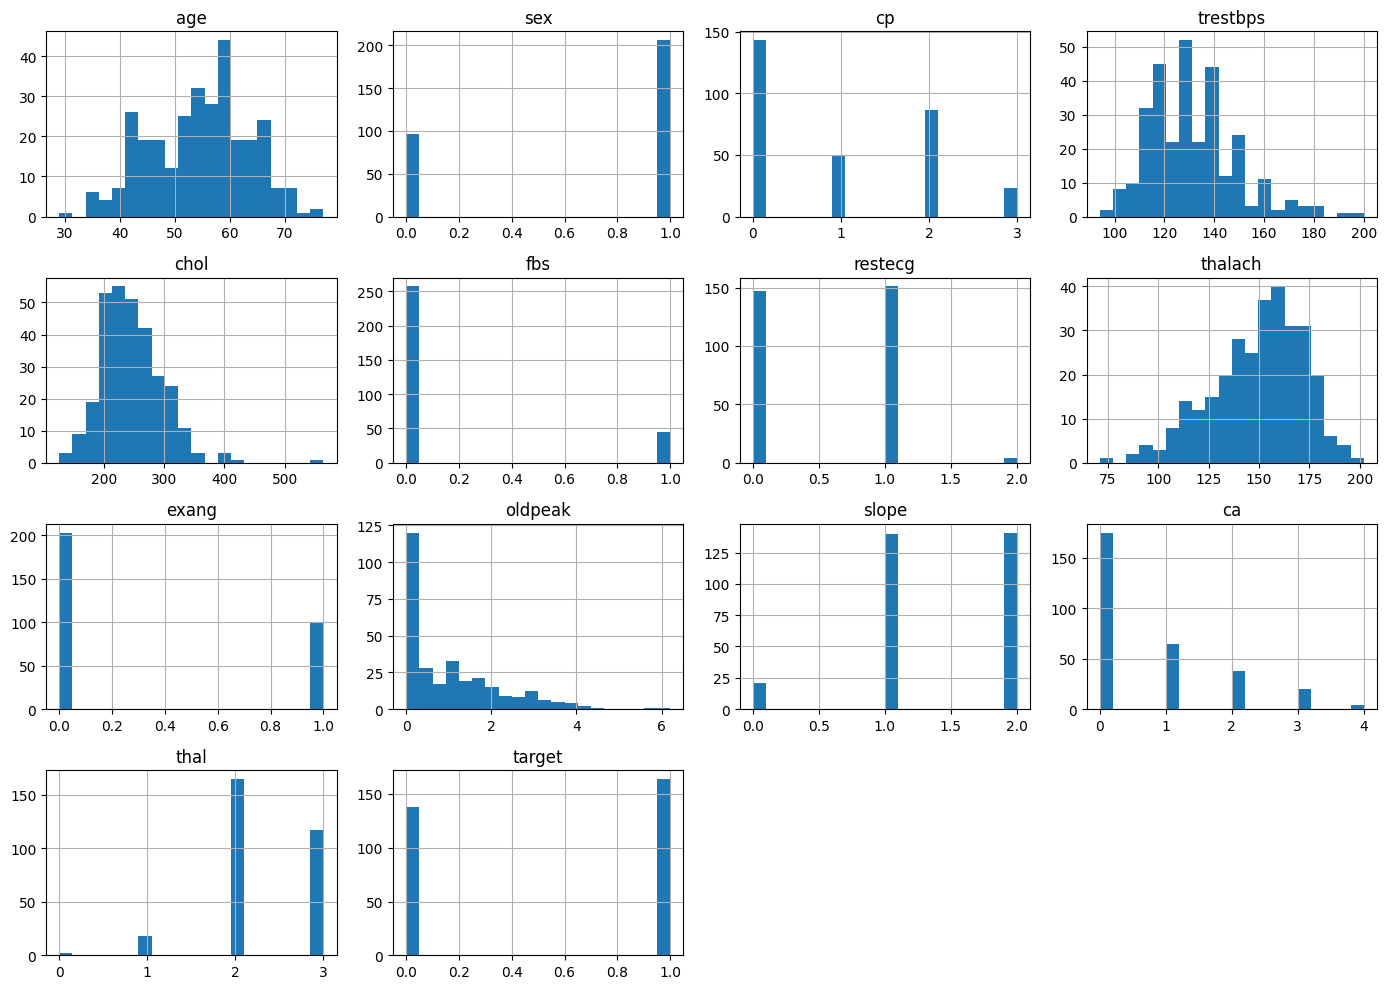

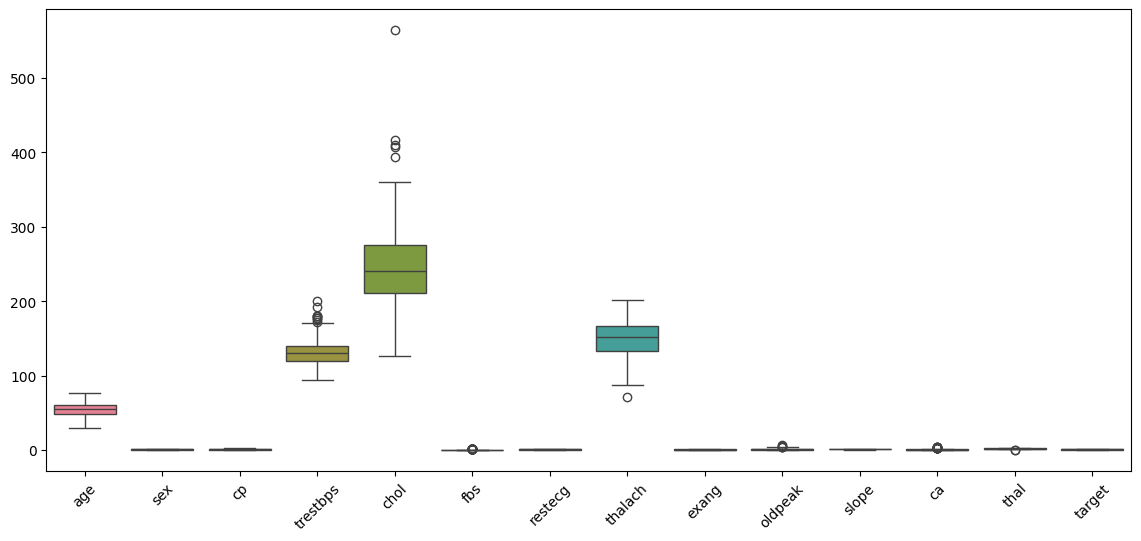

In [87]:


df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# Boxplots para verificar outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()

Vemosas distribuicões das variáveis, onde podemos fazer a identificaçao de outlier e termos uma visao do equilibrio das distribuiçoes dos dados.

## Ánalise de variáveis do tipo Numéricas contínuas

Analisando esses tipos de variáveis podemos identificar a tendência central, dispersão, outliers...
Colunas desse tipo:
* **age** (idade), **trestbps**(pressão arterial), **chol** (colesterol),**thalach** (frequência cardíaca máxima), **oldpeak** (depressão ST)

 Analisando somente a coluna da Idade:

In [88]:
df["age"].describe()


,age
count,302.00000
mean,54.42053
std,9.04797
min,29.00000
25%,48.00000
50%,55.50000
75%,61.00000
max,77.00000


Verificamos a idade min é de 29 e a máx é 77 anos, ou seja, não temos valores potenciais valores estranhos também.

In [89]:
df["sex"] = df["sex"].map({0: "Mulher", 1: "Homem"})


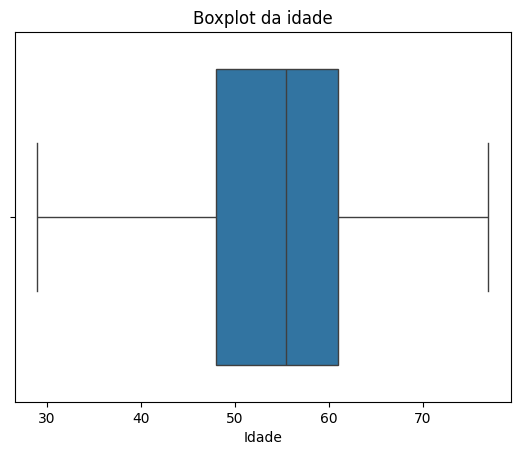

In [90]:
# Outliers
sns.boxplot(x=df["age"])
plt.xlabel("Idade")
plt.title("Boxplot da idade")
plt.show()


Com o boxplot, podemos verificar que não temos outliers nos dados.

### Análise da distribuição da coluna idade (em anos)

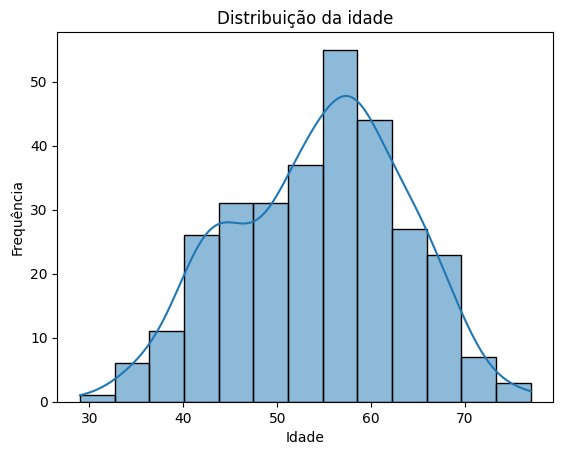

In [91]:
#Distribuição de idade
sns.histplot(df["age"],kde=True)
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.title("Distribuição da idade")
plt.show()


In [92]:
#Grafico da quantidade de homens e mulheres
alt.Chart(df).mark_bar().encode(
    x=alt.X('sex:O', title='Sexo'),
    y=alt.Y('count():Q', title='Quantidade'),
).properties(
    title='Quantidade por Sexo',
    width=300, #largura
    height=600 #altura
)

alt.Chart(...)

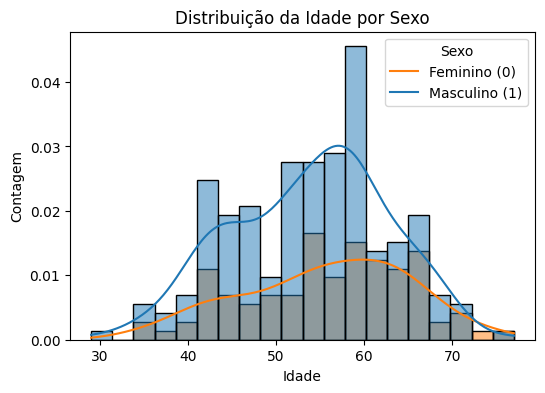

Estatística t: -1.6148283161207577
p-valor: 0.10814518162688283
Não há diferença significativa na idade média entre homens e mulheres.


In [93]:
import seaborn as sns
import matplotlib.pyplot as plt
# Distribuição das idades por sexo
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="age", hue="sex", kde=True, bins=20, alpha=0.5,stat="density" )
plt.title("Distribuição da Idade por Sexo")
plt.xlabel("Idade")
plt.ylabel("Contagem")
plt.legend(title="Sexo", labels=["Feminino (0)", "Masculino (1)"])
plt.show()

# Teste t
from scipy.stats import ttest_ind

idade_homens = df[df["sex"] == "Homem"]["age"]
idade_mulheres = df[df["sex"] == "Mulher"]["age"]

t_stat, p_value = ttest_ind(idade_homens, idade_mulheres, equal_var=False)

print("Estatística t:", t_stat)
print("p-valor:", p_value)

if p_value < 0.05:
    print("Há diferença significativa na idade média entre homens e mulheres.")
else:
    print("Não há diferença significativa na idade média entre homens e mulheres.")

In [94]:
df.groupby("sex")["age"].describe()


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Homem,206.0,53.834951,8.836838,29.0,47.00,54.5,59.75,77.0
Mulher,96.0,55.677083,9.409396,34.0,49.75,57.0,63.00,76.0


Análise: Há uma indicação de que as mulheres do estudo são, em geral, mais velhas. Como a idade é **fator de risco** para problemas cardíacos, isso pode influenciar os resultados clínicos (ex: pressão alta, angina, defeitos eletrocardiográficos) das mulheres.

In [95]:
import pandas as pd

# Ajuste os bins conforme o range das idades do seu dataset
bins = [29, 40, 50, 60, 70, 80]
labels = ['30-40', '41-50', '51-60', '61-70', '71-80']

df['Faixa_Idade'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)


In [96]:
tabela = df.groupby(['Faixa_Idade', 'sex', 'cp']).size().unstack(fill_value=0)
print(tabela)


cp                   0   1   2  3
Faixa_Idade sex                  
30-40       Homem    5   1   3  3
            Mulher   1   1   3  0
41-50       Homem   23  12  17  2
            Mulher   6   8   8  0
51-60       Homem   50  14  22  8
            Mulher  15   6  12  2
61-70       Homem   25   4   9  6
            Mulher  16   1  10  2
71-80       Homem    1   0   0  0
            Mulher   1   2   2  0


/tmp/ipython-input-436473530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela = df.groupby(['Faixa_Idade', 'sex', 'cp']).size().unstack(fill_value=0)


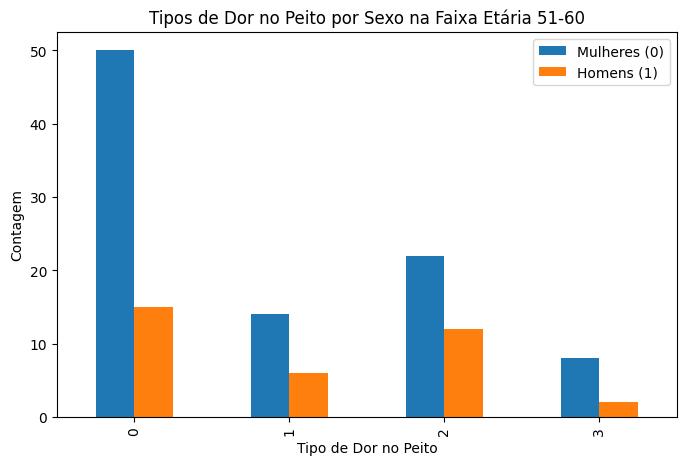

In [97]:
import matplotlib.pyplot as plt

faixa = '51-60'
dados_faixa = df[df['Faixa_Idade'] == faixa]

# Contar tipos de dor no peito por sexo
contagem = dados_faixa.groupby(['cp', 'sex']).size().unstack()

contagem.plot(kind='bar', figsize=(8,5))
plt.title(f'Tipos de Dor no Peito por Sexo na Faixa Etária {faixa}')
plt.xlabel('Tipo de Dor no Peito')
plt.ylabel('Contagem')
plt.legend(['Mulheres (0)', 'Homens (1)'])
plt.show()


Contagem absoluta:
sex  Homem  Mulher
cp                
0       50      15
1       14       6
2       22      12
3        8       2

Proporções (% dentro do sexo):
sex  Homem  Mulher
cp                
0     53.2    42.9
1     14.9    17.1
2     23.4    34.3
3      8.5     5.7


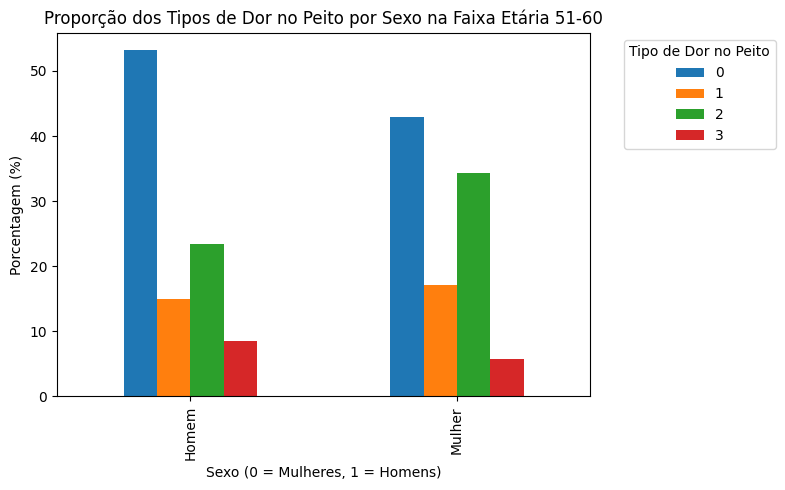

In [98]:
import pandas as pd
import matplotlib.pyplot as plt


faixa = '51-60'
df_faixa = df[df['Faixa_Idade'] == faixa]

# Conta o total por sexo para calcular as proporções
total_por_sexo = df_faixa.groupby('sex').size()

# Conta quantos para cada tipo de dor no peito por sexo
contagem = df_faixa.groupby(['cp', 'sex']).size().unstack(fill_value=0)

# Calcula a proporção dentro de cada sexo
proporcoes = contagem.div(total_por_sexo, axis=1) * 100  # em porcentagem

print("Contagem absoluta:")
print(contagem)
print("\nProporções (% dentro do sexo):")
print(proporcoes.round(1))


proporcoes.T.plot(kind='bar', figsize=(8,5))
plt.title(f'Proporção dos Tipos de Dor no Peito por Sexo na Faixa Etária {faixa}')
plt.xlabel('Sexo (0 = Mulheres, 1 = Homens)')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Tipo de Dor no Peito', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [99]:
df[['age','trestbps','chol','thalach','oldpeak']].describe()


,age,trestbps,chol,thalach,oldpeak
count,302.00000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046
std,9.04797,17.563394,51.753489,22.903527,1.161452
min,29.00000,94.000000,126.000000,71.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000
75%,61.00000,140.000000,274.750000,166.000000,1.600000
max,77.00000,200.000000,564.000000,202.000000,6.200000


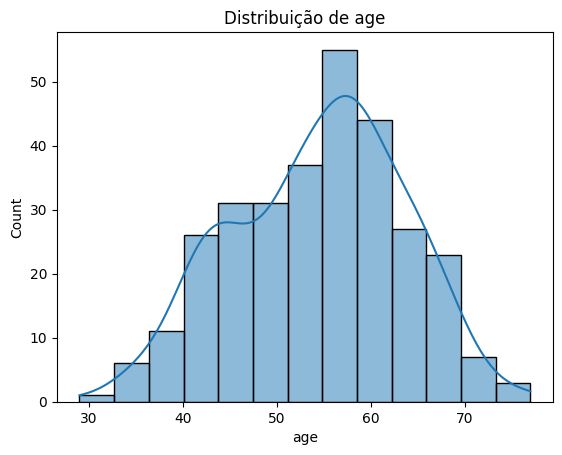

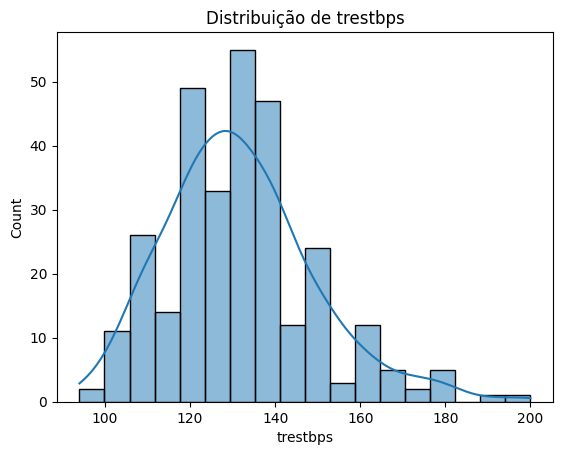

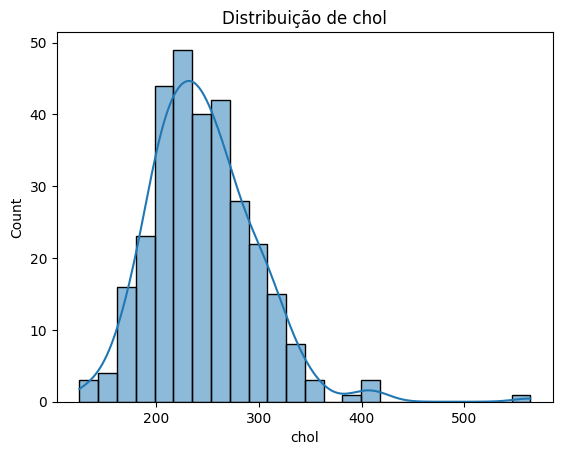

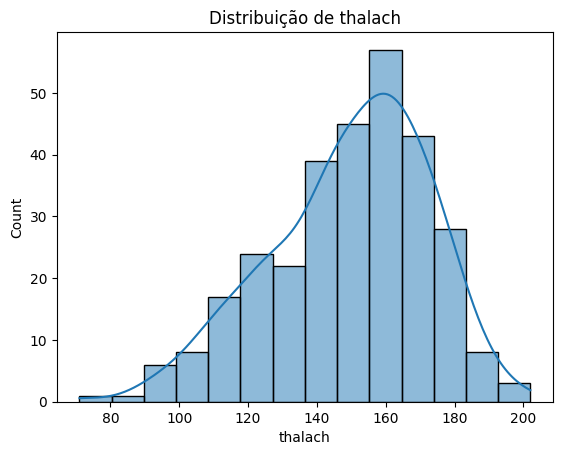

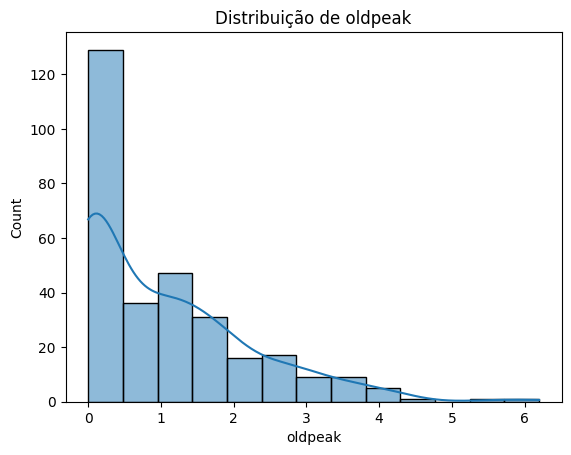

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['age','trestbps','chol','thalach','oldpeak']:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()


# Análise
* A distribuição de idades dos pacientes em nosso conjunto de dados revela que a maioria se concentra na faixa etária entre 50 e 60 anos. Essa concentração é clinicamente relevante, pois esta faixa etária é conhecida por apresentar maior incidência de problemas relacionados à saúde do coração.

* A pressão arterial se refere a força que o sangue exerce nas paredes das artérias quando é impulsionado pelo coração para ser levado a todo o corpo.

Em uma análise inicial dos dados de pressão arterial, focando especificamente na pressão sistólica, observamos as seguintes classificações de referência:

    Normal: Abaixo de 120 mmHg.
    Pré-hipertensão: Entre 120-139 mmHg.
    Hipertensão Estágio 1: Entre 140-159 mmHg.
    Hipertensão Estágio 2: Acima de 160 mmHg.

Ao analisar a distribuição da nossa amostra de pacientes, notamos que a grande maioria dos valores dos dados está concentrada na faixa entre 120 e 140 mmHg. Isso nos coloca majoritariamente nas categorias de pré-hipertensão e início da hipertensão estágio 1, que são, essencialmente, os estágios iniciais de um problema mais sério de saúde cardiovascular, indicando a necessidade de intervenção e monitoramento imediatos.

* Colesterol: A maior parte dos pacientes analisados apresenta Colesterol Total elevado, na faixa considerada limítrofe a alta (200 a 300 mg/dL).

Existe uma correlação a ser analisada: se esses pacientes, com esses níveis de colesterol, apresentam doença cardíaca, isso reforça a tese médica de que níveis elevados de colesterol total são um fator de risco significativo e estão associados a desfechos negativos (a presença da doença).

* A variável oldpeak representa a depressão do segmento ST observada durante o teste de esforço em relação ao repouso. Valores próximos de 0 indicam ausência de alteração significativa, enquanto valores maiores refletem maior nível de isquemia miocárdica, ou seja, um indício de menor oxigenação do músculo cardíaco durante o exercício.

Ao observar o histograma dessa variável, nota-se uma forte concentração de valores próximos de 0, com poucos casos apresentando valores mais altos (acima de 2). Essa distribuição assimétrica à direita sugere que a maioria dos pacientes do conjunto de dados não apresentou sinais de anormalidade cardíaca significativa, enquanto apenas uma pequena parcela apresentou valores que podem indicar condições mais graves.

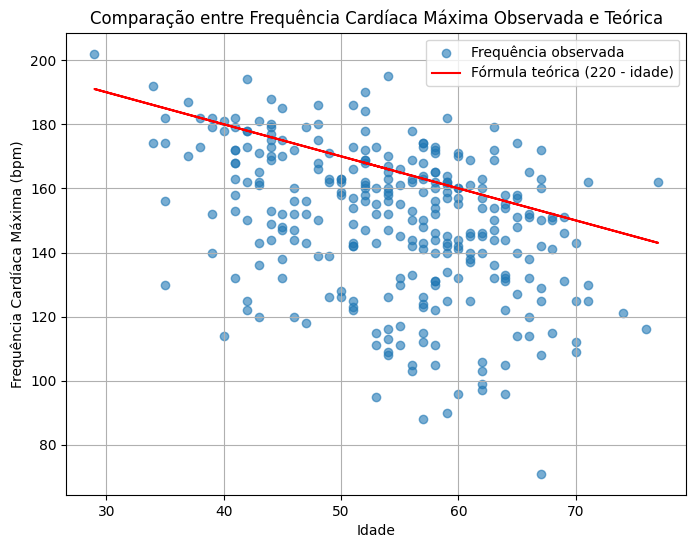

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que o seu DataFrame se chame df
# e que as colunas sejam 'age' e 'thalach'

# Calcula a frequência máxima teórica
df['max_teorica'] = 220 - df['age']

# Cria o gráfico
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['thalach'], alpha=0.6, label='Frequência observada')
plt.plot(df['age'], df['max_teorica'], color='red', label='Fórmula teórica (220 - idade)')
plt.xlabel('Idade')
plt.ylabel('Frequência Cardíaca Máxima (bpm)')
plt.title('Comparação entre Frequência Cardíaca Máxima Observada e Teórica')
plt.legend()
plt.grid(True)
plt.show()


A variável thalach representa a frequência cardíaca máxima observada para cada indivíduo do conjunto de dados. Para verificar a coerência dos valores registrados, foi realizada uma comparação com a frequência cardíaca máxima teórica, obtida pela fórmula 220−idade. Essa análise exploratória permitiu observar o comportamento da frequência cardíaca em relação à idade, avaliando se os dados seguem o padrão esperado de diminuição da frequência máxima conforme o aumento da idade. Além disso, a comparação auxilia na identificação de possíveis outliers ou registros inconsistentes, contribuindo para a compreensão da distribuição e da qualidade dos dados.

<Axes: xlabel='oldpeak'>

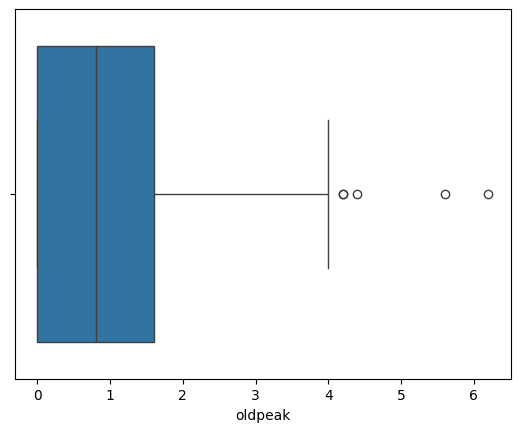

In [102]:
import seaborn as sns
sns.boxplot(x=df['oldpeak'])



<Axes: >

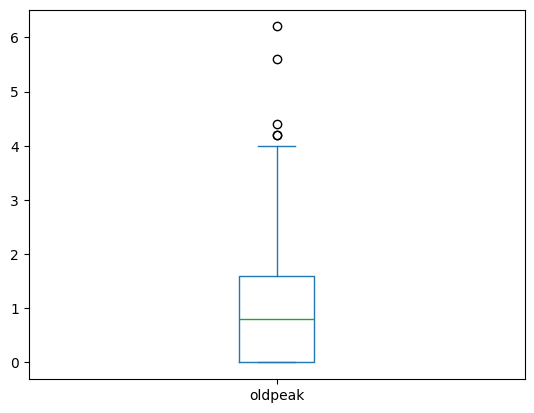

In [103]:
df['oldpeak'].plot.box()


In [104]:
Q1 = df['oldpeak'].quantile(0.25)
Q3 = df['oldpeak'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
df[df['oldpeak'] > limite_superior]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Faixa_Idade,max_teorica
6,58,Homem,0,114,318,0,2,140,0,4.4,0,3,1,0,51-60,162
13,51,Homem,0,140,298,0,1,122,1,4.2,1,3,3,0,51-60,169
51,55,Homem,0,140,217,0,1,111,1,5.6,0,0,3,0,51-60,165
63,62,Mulher,0,160,164,0,0,145,0,6.2,0,3,3,0,61-70,158
271,59,Homem,3,178,270,0,0,145,0,4.2,0,0,3,1,51-60,161


In [105]:
df['sex'].value_counts(normalize=True) * 100
df['cp'].value_counts()


,count
cp,
0,143
2,86
1,50
3,23


In [106]:
import altair as alt

alt.Chart(df).mark_bar().encode(
    x=alt.X('count()', title='Contagem'),
    y=alt.Y('cp:O', title='Tipo de dor no peito'),
    color='cp:N'
).properties(title='Distribuição de tipo de dor no peito')


alt.Chart(...)

## Análise de dados do tipo Numérica discreta



/tmp/ipython-input-836826528.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ca', data=df, palette='viridis')


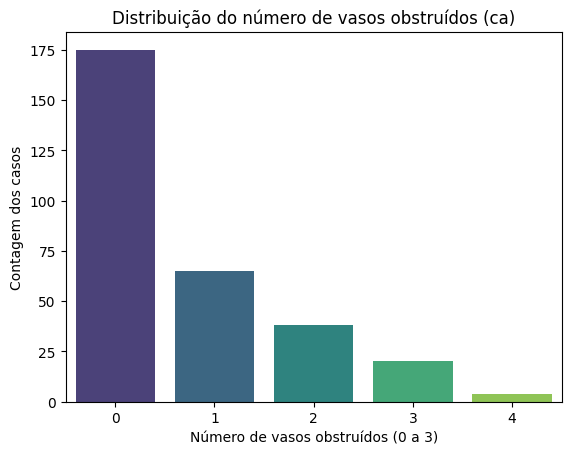

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='ca', data=df, palette='viridis')
plt.title('Distribuição do número de vasos obstruídos (ca)')
plt.xlabel('Número de vasos obstruídos (0 a 3)')
plt.ylabel('Contagem dos casos')
plt.show()


In [108]:
freq_ca = df['ca'].value_counts().sort_index()
percent_ca = df['ca'].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({'Frequência Absoluta': freq_ca, 'Frequência Relativa (%)': percent_ca.round(2)})


,Frequência Absoluta,Frequência Relativa (%)
ca,,
0,175,57.95
1,65,21.52
2,38,12.58
3,20,6.62
4,4,1.32


In [109]:
df['ca'].describe()


,ca
count,302.000000
mean,0.718543
std,1.006748
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,4.000000


A coluna `ca` representa quantos vasos principais (entre 0 e 3) mostraram obstração. Caso haja valores maiores isso pode indicar maior gravidade da doença coronariana.
Nesse caso, uma análise posterior pode ser feita relacionando com a coluna do colesterol e com a coluna que representa o tipo de dor no peito, para identificarmos possíveis relações entre essas variáveis.
* Com a estatística descritiva verificamos que a média está mais próxima de 0,ou seja, **a maioria com poucos vasos obstruídos**;  

Assim pela análise, a variável `ca` apresenta distribuição assimétrica, com a maioria dos pacientes possuindo poucos vasos obstruídos (valores próximos de 0). Pacientes com valores mais altos de ca são minoria, mas podem indicar casos de doença cardíaca mais grave. Essa tendência poderá ser confirmada explorando a relação entre ca e a variável-alvo `target`.

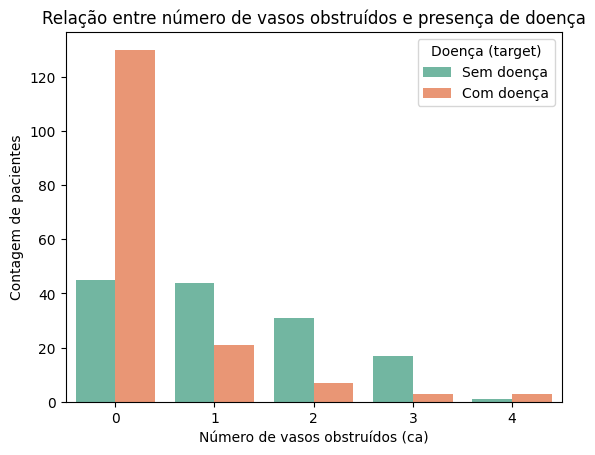

In [110]:
sns.countplot(x='ca', hue='target', data=df, palette='Set2')
plt.title('Relação entre número de vasos obstruídos e presença de doença')
plt.xlabel('Número de vasos obstruídos (ca)')
plt.ylabel('Contagem de pacientes')
plt.legend(title='Doença (target)', labels=['Sem doença', 'Com doença'])
plt.show()


Ao comparar `ca` com a variável-alvo (`target`), observou-se que muitas pessoas diagnosticadas com doença cardíaca (`target = 1`) também possuem `ca = 0`. Isso sugere que a presença de doença nem sempre está associada à obstrução detectável em grandes vasos, podendo envolver outros fatores cardíacos funcionais. Assim, `ca` isoladamente não distingue bem entre indivíduos saudáveis e doentes, mas pode ter importância combinada com outras variáveis clínicas.

/tmp/ipython-input-86883878.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='oldpeak', data=df_sem_obstrucao, palette='coolwarm', ax=axes[0])


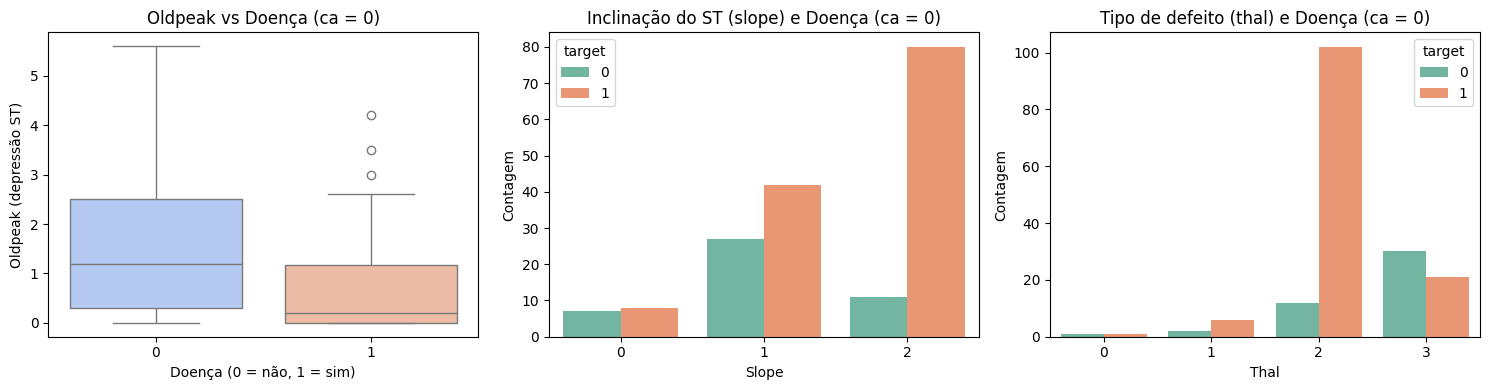

In [111]:
df_sem_obstrucao = df[df['ca'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# oldpeak
sns.boxplot(x='target', y='oldpeak', data=df_sem_obstrucao, palette='coolwarm', ax=axes[0])
axes[0].set_title('Oldpeak vs Doença (ca = 0)')
axes[0].set_xlabel('Doença (0 = não, 1 = sim)')
axes[0].set_ylabel('Oldpeak (depressão ST)')

# slope
sns.countplot(x='slope', hue='target', data=df_sem_obstrucao, palette='Set2', ax=axes[1])
axes[1].set_title('Inclinação do ST (slope) e Doença (ca = 0)')
axes[1].set_xlabel('Slope')
axes[1].set_ylabel('Contagem')

# thal
sns.countplot(x='thal', hue='target', data=df_sem_obstrucao, palette='Set2', ax=axes[2])
axes[2].set_title('Tipo de defeito (thal) e Doença (ca = 0)')
axes[2].set_xlabel('Thal')
axes[2].set_ylabel('Contagem')

plt.tight_layout()
plt.show()


**Entre os que não têm obstrução nos vasos, quais fatores funcionais indicam doença?**

Para compreender por que muitos indivíduos com ca = 0 ainda apresentam diagnóstico positivo de doença, foram analisadas variáveis clínicas associadas à função cardíaca, como oldpeak , slope e thal.
Observou-se que indivíduos com valores 1 ou 2 de slope e com defeitos reversíveis (thal = 2) apresentam maior incidência de doença, mesmo sem obstrução visível nos grandes vasos. Esses achados sugerem que a detecção de anormalidades elétricas ou funcionais do coração também desempenha papel importante no diagnóstico, complementando as informações fornecidas por ca.

## Análise das variáveis do tipo categóricas nominais

No dataset são: `sex, cp, restecg, thal, terget`

/tmp/ipython-input-559305797.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='Set2', ax=ax[0])


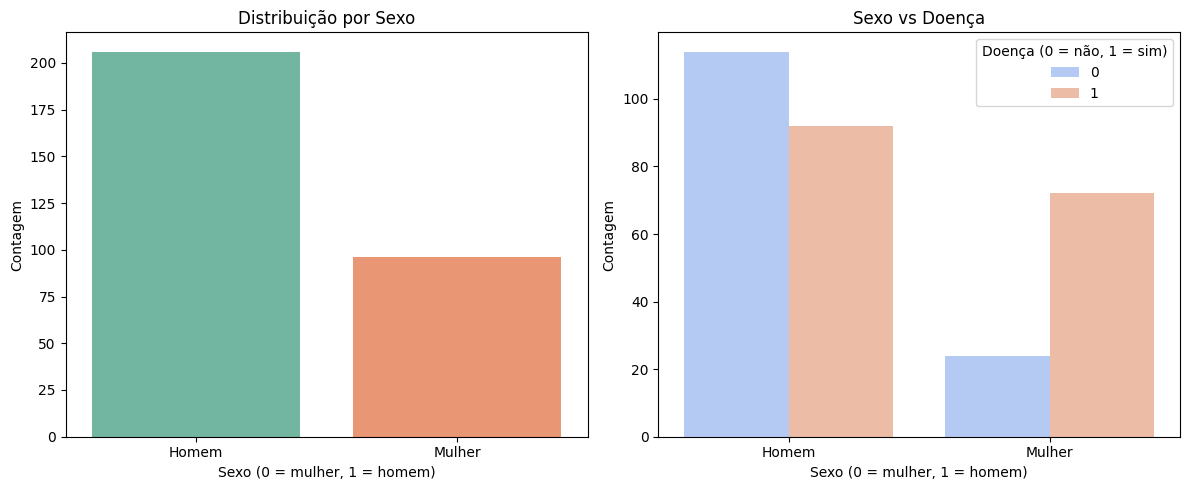

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Distribuição de sexos
sns.countplot(x='sex', data=df, palette='Set2', ax=ax[0])
ax[0].set_title('Distribuição por Sexo')
ax[0].set_xlabel('Sexo (0 = mulher, 1 = homem)')
ax[0].set_ylabel('Contagem')

# Relação entre sexo e presença de doença
sns.countplot(x='sex', hue='target', data=df, palette='coolwarm', ax=ax[1])
ax[1].set_title('Sexo vs Doença')
ax[1].set_xlabel('Sexo (0 = mulher, 1 = homem)')
ax[1].set_ylabel('Contagem')
ax[1].legend(title='Doença (0 = não, 1 = sim)')

plt.tight_layout()
plt.show()


In [113]:
# Agrupa por sexo e calcula a taxa de doença dentro de cada grupo
sex_stats = df.groupby('sex')['target'].mean()
sex_stats.index = sex_stats.index.map({0: 'Mulheres', 1: 'Homens'})
sex_stats = (
    df.groupby('sex')['target']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'Total', 'sum': 'Com doença', 'mean': 'Proporção_doença'})
)

sex_stats['Proporção_doença'] = (sex_stats['Proporção_doença'] * 100).round(2)

sex_stats


,Total,Com doença,Proporção_doença
sex,,,
Homem,206,92,44.66
Mulher,96,72,75.00


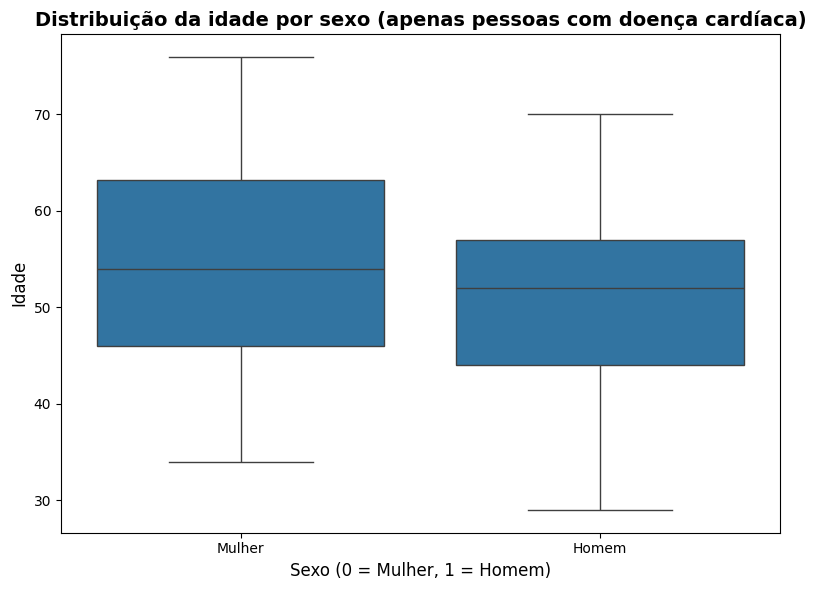

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtra apenas quem tem doença cardíaca
df_disease = df[df['target'] == 1].copy()

# Gráfico: distribuição das idades by sex for people with heart disease
plt.figure(figsize=(8, 6))
sns.boxplot(x='sex', y='age', data=df_disease)

plt.title('Distribuição da idade por sexo (apenas pessoas com doença cardíaca)', fontsize=14, weight='bold')
plt.xlabel('Sexo (0 = Mulher, 1 = Homem)', fontsize=12)
plt.ylabel('Idade', fontsize=12)
plt.xticks([0, 1], ['Mulher', 'Homem']) # Set the tick labels
plt.tight_layout()
plt.show()

A análise revelou que, embora o conjunto de dados apresente um número maior de homens, **a proporção de mulheres com doença cardíaca é superior**. No entanto, ao relacionar essa informação com a idade, observou-se que as **mulheres acometidas pela doença tendem a ser mais velhas**, enquanto os **homens manifestam a condição em idades mais jovens**. Esse comportamento sugere que a diferença de prevalência entre os sexos pode estar associada à faixa etária, **reforçando a hipótese de que as doenças cardíacas surgem mais tardiamente nas mulheres e de forma mais antecipada nos homens.**

/tmp/ipython-input-1877696697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cp', data=df, palette='viridis')


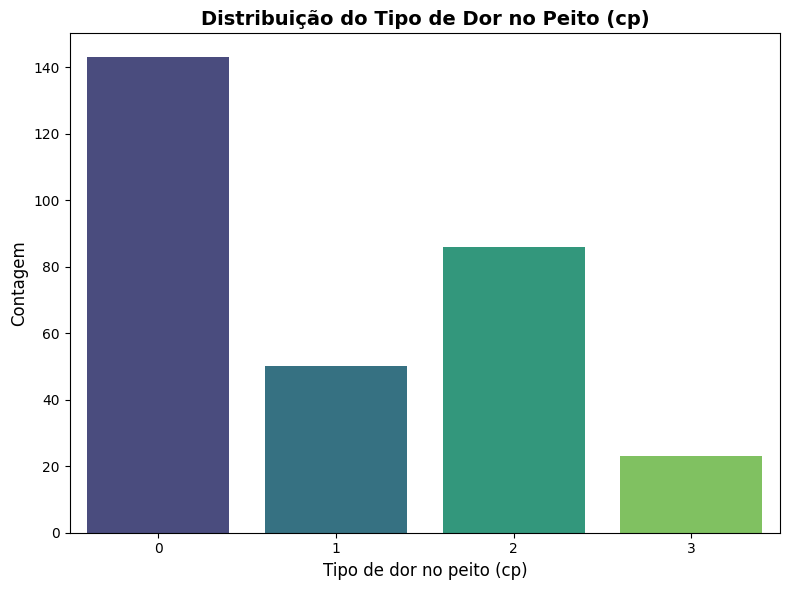

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='cp', data=df, palette='viridis')

plt.title('Distribuição do Tipo de Dor no Peito (cp)', fontsize=14, weight='bold')
plt.xlabel('Tipo de dor no peito (cp)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.tight_layout()
plt.show()


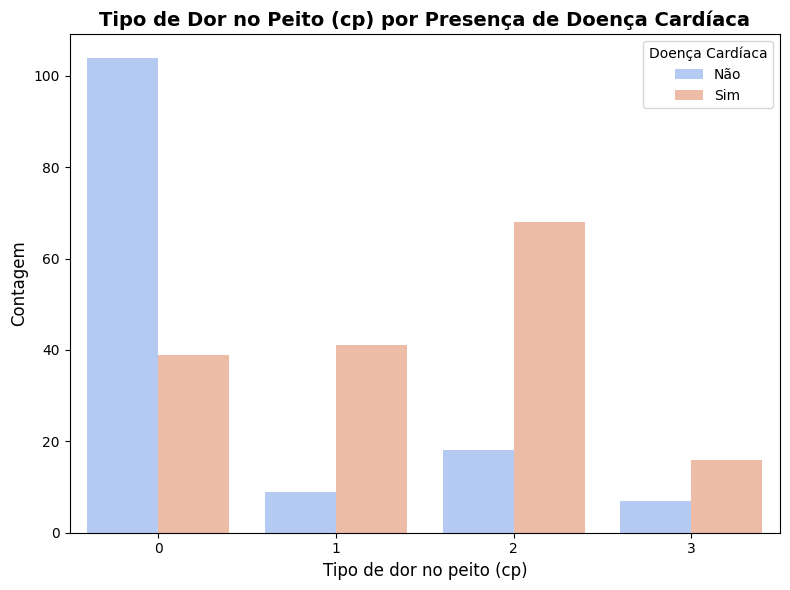

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(
    x='cp', hue='target', data=df, palette='coolwarm'
)

plt.title('Tipo de Dor no Peito (cp) por Presença de Doença Cardíaca', fontsize=14, weight='bold')
plt.xlabel('Tipo de dor no peito (cp)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.legend(title='Doença Cardíaca', labels=['Não', 'Sim'])
plt.tight_layout()
plt.show()


A variável cp representa o tipo de dor no peito, variando de 0 (angina típica) até 3 (assintomático).
Ao analisar o conjunto de dados, observa-se que à medida que o valor de cp aumenta, também aumenta a proporção de indivíduos com doença cardíaca.
Ou seja, pessoas com cp = 0 tendem a não apresentar a doença, enquanto aquelas com cp = 2 e cp = 3 (dor não anginosa ou ausência de dor) têm maior probabilidade de diagnóstico positivo.

Esse padrão sugere que, neste dataset, a presença de sintomas típicos de dor no peito nem sempre indica maior risco, enquanto casos assintomáticos ou com dores atípicas estão mais associados à doença, possivelmente refletindo diagnósticos feitos em estágios mais avançados ou com base em outros fatores clínicos.

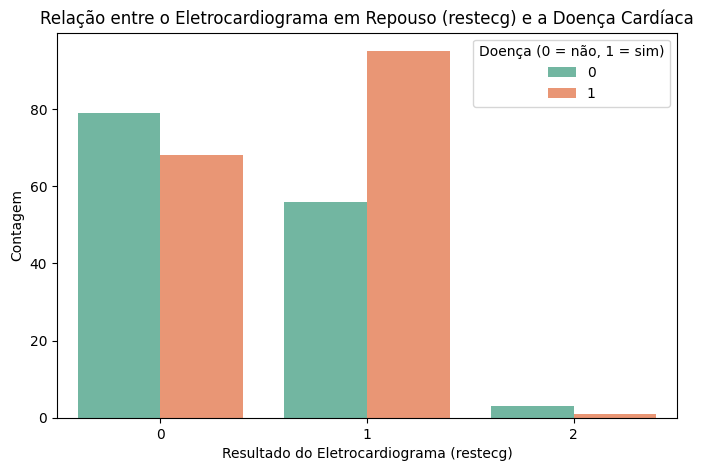

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='restecg', hue='target', data=df, palette='Set2')
plt.title('Relação entre o Eletrocardiograma em Repouso (restecg) e a Doença Cardíaca')
plt.xlabel('Resultado do Eletrocardiograma (restecg)')
plt.ylabel('Contagem')
plt.legend(title='Doença (0 = não, 1 = sim)')
plt.show()


In [118]:
# Calculando a proporção de doença em cada categoria de restecg
restecg_stats = df.groupby('restecg')['target'].agg(
    Total='count',
    Com_doenca='sum'
)
restecg_stats['Proporcao_doenca'] = (restecg_stats['Com_doenca'] / restecg_stats['Total']) * 100
print(restecg_stats)


         Total  Com_doenca  Proporcao_doenca
restecg                                     
0          147          68         46.258503
1          151          95         62.913907
2            4           1         25.000000


A análise da variável **restecg** (resultado do eletrocardiograma em repouso) mostra que a maioria dos indivíduos se enquadra nas categorias 0 e 1. Observa-se que pessoas com **restecg = 1**, indicando anormalidades no traçado do ECG, apresentam a **maior proporção de doença cardíaca aproximadamente 63%**, enquanto aquelas com **restecg = 0**, geralmente com ECG normal, têm uma proporção menor, cerca de 46%. Já o grupo com **restecg = 2**, associado a anormalidades mais específicas, é pequeno na amostra e apresenta uma proporção de 25%. Esses resultados sugerem que alterações detectadas no ECG em repouso estão associadas a maior probabilidade de presença de doença cardíaca.


In [119]:
import pandas as pd

contagem = {0: 0, 1: 0, 2: 0, 3: 0, 'NaN': 0, 'Outros': 0}

for val in df['thal']:
    if pd.isna(val):
        contagem['NaN'] += 1
    else:
        try:
            v = int(val)  # converte float para int, ex: 1.0 -> 1
            if v in contagem:
                contagem[v] += 1
            else:
                contagem['Outros'] += 1
        except:
            contagem['Outros'] += 1

print("Contagem dos valores na coluna 'thal':")
for chave, qtd in contagem.items():
    print(f"Valor {chave}: {qtd} linhas")


Contagem dos valores na coluna 'thal':
Valor 0: 2 linhas
Valor 1: 18 linhas
Valor 2: 165 linhas
Valor 3: 117 linhas
Valor NaN: 0 linhas
Valor Outros: 0 linhas


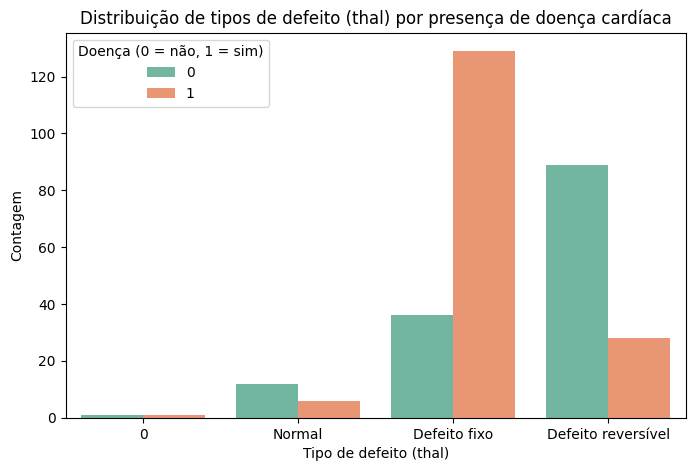

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapear valores para nomes claros
thal_labels = {0: '0', 1: 'Normal', 2: 'Defeito fixo', 3: 'Defeito reversível'}
df['thal_label'] = df['thal'].map(thal_labels)

plt.figure(figsize=(8,5))
sns.countplot(x='thal_label', hue='target', data=df, palette='Set2', order=['0', 'Normal', 'Defeito fixo', 'Defeito reversível'])

plt.title('Distribuição de tipos de defeito (thal) por presença de doença cardíaca')
plt.xlabel('Tipo de defeito (thal)')
plt.ylabel('Contagem')
plt.legend(title='Doença (0 = não, 1 = sim)')
plt.show()


In [128]:
tabela_thal = df.groupby('thal_label').agg(
    Total=('target', 'count'),
    Com_doenca=('target', 'sum')
)
tabela_thal['Proporcao_doenca'] = (tabela_thal['Com_doenca'] / tabela_thal['Total'] * 100).round(2)

print(tabela_thal)


                    Total  Com_doenca  Proporcao_doenca
thal_label                                             
0                       2           1             50.00
Defeito fixo          165         129             78.18
Defeito reversível    117          28             23.93
Normal                 18           6             33.33


A variável thal refere-se ao tipo de defeito observado no exame de tálio, que é um método utilizado para detectar problemas cardíacos através da perfusão do miocárdio. No dataset, essa variável é categorizada em quatro grupos:

* **Normal**: Ausência de defeito na perfusão (18 registros)

* **Defeito fixo**: Áreas do coração com perfusão permanentemente comprometida, indicando possível tecido cicatricial (165 registros)

* **Defeito reversível**: Áreas com perfusão reduzida apenas durante o estresse, sugerindo isquemia transitória (117 registros)

Analisando a relação com a presença de doença cardíaca:

* A maior proporção de pacientes com doença está no grupo de **defeito fixo (78,18%)**, o que é esperado, pois essa categoria indica danos permanentes no tecido cardíaco.

* O grupo de **defeito reversível** apresenta uma proporção de doença significativamente menor (23,93%), indicando que nem todos com este tipo de defeito possuem um diagnóstico confirmado de doença cardíaca.

* Curiosamente, o grupo classificado como normal também apresenta uma proporção de doença de 33,33%, o que pode indicar diagnósticos clínicos baseados em outros critérios ou possíveis limitações no exame de tálio.

Esses resultados ressaltam a importância da variável thal na avaliação diagnóstica, especialmente a presença de defeitos fixos que estão fortemente associados à doença cardíaca no conjunto de dados analisado. Ao mesmo tempo, evidencia que a variável, embora relevante, deve ser interpretada junto com outros indicadores clínicos para um diagnóstico mais completo. Já os casos da categoria 0, sugerem ser outliers no conjunto.

     Total  Com_doenca  Proporcao_doenca
fbs                                     
0      257         141         54.863813
1       45          23         51.111111


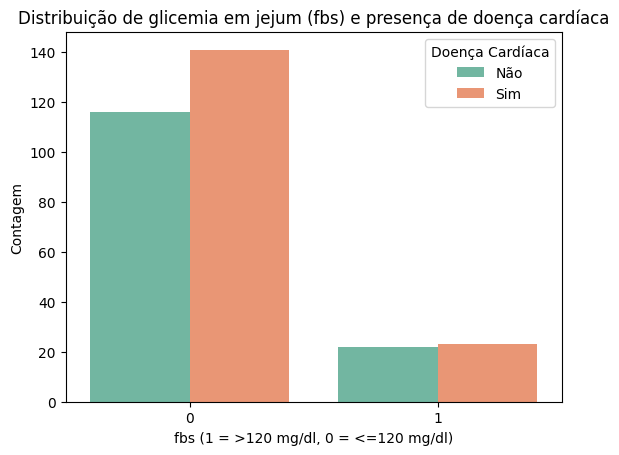

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tabela de frequência e proporção
tabela_fbs = df.groupby('fbs')['target'].agg(['count', 'sum'])
tabela_fbs.columns = ['Total', 'Com_doenca']
tabela_fbs['Proporcao_doenca'] = (tabela_fbs['Com_doenca'] / tabela_fbs['Total']) * 100
print(tabela_fbs)

# Gráfico
sns.countplot(x='fbs', hue='target', data=df, palette='Set2')
plt.title('Distribuição de glicemia em jejum (fbs) e presença de doença cardíaca')
plt.xlabel('fbs (1 = >120 mg/dl, 0 = <=120 mg/dl)')
plt.ylabel('Contagem')
plt.legend(title='Doença Cardíaca', labels=['Não', 'Sim'])
plt.show()


A variável fbs representa o nível de glicose no sangue em jejum, sendo codificada como:

* 0: menor ou igual a 120 mg/dl

* 1: maior que 120 mg/dl

Essa variável é utilizada como um indicador de possíveis distúrbios metabólicos, como a diabetes, que pode estar relacionada a um maior risco de doenças cardíacas.

Na análise, observa-se que indivíduos com níveis normais de glicose (fbs = 0) apresentam uma proporção de doença cardíaca de aproximadamente 54,9%, enquanto aqueles com níveis elevados (fbs = 1) possuem uma proporção levemente menor, de 51,1%.
Isso sugere que, **neste conjunto de dados**, o **nível de glicose em jejum não se mostrou um fator determinante isolado** na presença de doença cardíaca, já que as proporções de ocorrência são próximas. Contudo, essa variável pode ainda contribuir **em combinação com outras características clínicas**, como pressão arterial e colesterol, para indicar risco cardiovascular.

/tmp/ipython-input-3088116464.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Doença Cardíaca', data=df, palette='Set2')


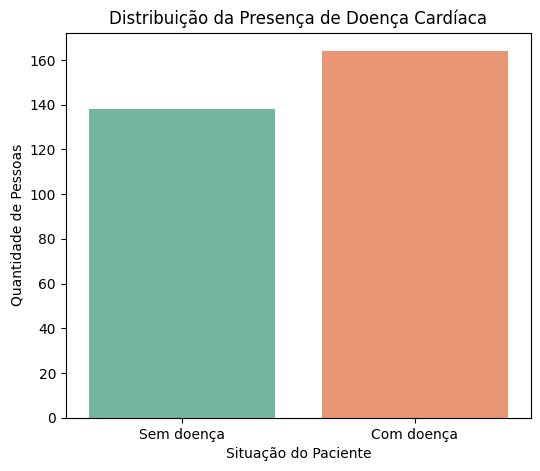

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapeando para nomes mais compreensíveis
df['Doença Cardíaca'] = df['target'].map({0: 'Sem doença', 1: 'Com doença'})

# Gráfico de contagem
plt.figure(figsize=(6, 5))
sns.countplot(x='Doença Cardíaca', data=df, palette='Set2')
plt.title('Distribuição da Presença de Doença Cardíaca')
plt.xlabel('Situação do Paciente')
plt.ylabel('Quantidade de Pessoas')
plt.show()


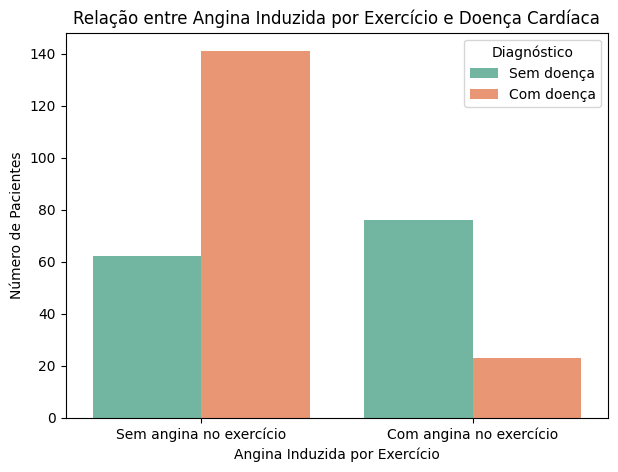

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mapeando para tornar os rótulos mais compreensíveis
df['Angina_exercicio'] = df['exang'].map({0: 'Sem angina no exercício', 1: 'Com angina no exercício'})
df['Doença Cardíaca'] = df['target'].map({0: 'Sem doença', 1: 'Com doença'})

plt.figure(figsize=(7, 5))
sns.countplot(x='Angina_exercicio', hue='Doença Cardíaca', data=df, palette='Set2')

plt.title('Relação entre Angina Induzida por Exercício e Doença Cardíaca')
plt.xlabel('Angina Induzida por Exercício')
plt.ylabel('Número de Pacientes')
plt.legend(title='Diagnóstico')
plt.show()


In [126]:
# Contagem de cada valor de exang
print(df['exang'].value_counts())

# Contagem cruzada entre exang e target
print(pd.crosstab(df['exang'], df['target'], margins=True))


exang
0    203
1     99
Name: count, dtype: int64
target    0    1  All
exang                
0        62  141  203
1        76   23   99
All     138  164  302


A variável **angina induzida por exercício (exang)** indica se o paciente apresentou dor no peito durante esforço físico (`1` para sim e `0` para não). Embora se espere que pacientes com angina induzida por exercício tenham maior incidência de doença cardíaca, a análise dos dados mostrou que muitos pacientes com doença cardíaca não apresentaram angina durante o exercício.

Isso evidencia que a angina induzida por exercício não é o único sintoma ou indicador de doença cardíaca, refletindo a complexidade clínica da doença e a variedade de suas manifestações. Portanto, a ausência de angina durante o exercício não exclui a possibilidade de diagnóstico positivo para doença cardíaca, reforçando a importância de uma avaliação clínica abrangente.

Além das considerações clínicas, não se pode descartar a possibilidade de inconsistências ou erros no dataset original, como codificações incorretas ou registros incompletos, que podem afetar a interpretação da variável **angina induzida por exercício (exang)**. Por isso, é importante tratar essa variável com cautela e, se possível, validar os dados com outras fontes ou informações clínicas complementares.

## **Conclusão da Análise Exploratória**

Nesta análise exploratória do dataset de doenças cardíacas, foram investigadas diversas variáveis de diferentes tipos (numéricas contínuas, discretas, categóricas, binárias e ordinais) em relação à presença ou ausência de doença cardíaca.

Os principais achados incluem:

* **Idade e sexo**: Observou-se que a proporção de mulheres com doença cardíaca é maior que a dos homens, porém as mulheres tendem a desenvolver a doença em idades mais avançadas, enquanto os homens apresentam diagnóstico em faixas etárias mais jovens.

* **Tipo de dor no peito (cp)**: Tipos de dor classificados como angina atípica, dor não anginosa e assintomática estão mais associados à presença de doença cardíaca, enquanto a angina típica aparece mais em pacientes sem doença, indicando uma relação relevante dessa variável com o diagnóstico.

* **Eletrocardiograma em repouso (restecg) e tipo de defeito no tálio (thal)**  mostraram correlações significativas com a presença da doença cardíaca. Em especial, a variável thal demonstrou que pacientes com defeito fixo possuem maior prevalência de doença (78%), enquanto os com defeito reversível apresentam uma proporção menor (24%). Pacientes com exame normal ainda apresentaram uma proporção considerável de diagnóstico (33%), o que sugere a necessidade de interpretação cuidadosa em conjunto com outras variáveis clínicas.

* **Glicemia em jejum (fbs) e angina induzida por exercício (exang)** mostraram resultados que indicam a necessidade de cautela na interpretação, pois apresentaram padrões não totalmente alinhados às expectativas clínicas, possivelmente por características específicas da amostra ou limitações do dataset.

* **Variáveis como pressão arterial, colesterol e oldpeak** indicam tendências esperadas, mas sem correlações muito fortes com a presença da doença, sugerindo que isoladamente podem não ser bons preditores.

Adicionalmente, observou-se a presença de categorias pouco frequentes ou dados ausentes em algumas variáveis, reforçando a importância de um pré-processamento cuidadoso para garantir qualidade e consistência nos dados utilizados para modelagem.

Por fim, esta análise exploratória fornece uma base sólida para entender o comportamento das variáveis e suas relações com a doença cardíaca, orientando as próximas etapas de modelagem e validação. Também destaca a importância de considerar possíveis limitações e peculiaridades do conjunto de dados para uma interpretação mais precisa.

